Import data

In [5]:
import pandas as pd

df = pd.read_parquet('hotels_data_final_project.parquet')

df.head()

,unique_id,ds,holiday_flag,target_day,target_month,target_year,location_type,hotel_type,y,otb_1,...,otb_51,otb_52,otb_53,otb_54,otb_55,otb_56,otb_57,otb_58,otb_59,otb_60
1430,hotel_0,2022-01-01,no,Sat,Jan,2022,NonSuburban,Resorts & Destinations,0.975309,0.679012,...,0.197531,0.197531,0.197531,0.185185,0.160494,0.160494,0.160494,0.160494,0.160494,0.160494
1431,hotel_0,2022-01-02,no,Sun,Jan,2022,NonSuburban,Resorts & Destinations,0.493827,0.308642,...,0.074074,0.074074,0.074074,0.074074,0.074074,0.061728,0.061728,0.061728,0.061728,0.049383
1432,hotel_0,2022-01-03,no,Mon,Jan,2022,NonSuburban,Resorts & Destinations,0.456790,0.358025,...,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691
1433,hotel_0,2022-01-04,no,Tue,Jan,2022,NonSuburban,Resorts & Destinations,0.592593,0.419753,...,0.074074,0.074074,0.074074,0.074074,0.061728,0.061728,0.037037,0.037037,0.024691,0.024691
1434,hotel_0,2022-01-05,no,Wed,Jan,2022,NonSuburban,Resorts & Destinations,0.530864,0.407407,...,0.074074,0.074074,0.074074,0.074074,0.074074,0.049383,0.049383,0.024691,0.024691,0.012346


Check Data

In [6]:
df.columns
df.info
df['unique_id'].nunique()
df.isnull().sum()

,0
unique_id,0
ds,0
holiday_flag,0
target_day,0
target_month,0
...,...
otb_56,0
otb_57,0
otb_58,0
otb_59,0


Standardize data

In [7]:
df = df[['unique_id', 'ds', 'y']].copy()
df_full = df.copy()

df = df.sort_values(['unique_id', 'ds'])

df_stats = df[['unique_id', 'ds', 'y']]

df_ml = df.copy()

df['ds'].diff().value_counts().head()

df.groupby('unique_id').size().head()

,0
unique_id,
hotel_0,546
hotel_105,546
hotel_112,546
hotel_126,546
hotel_133,546


Install libraries

In [8]:
!pip install statsforecast
!pip install mlforecast
!pip install neuralforecast
!pip install utilsforecast
!pip install lightgbm
!pip install datasetsforecast

Import packages

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsforecast import StatsForecast
from statsforecast.models import (
    Naive,
    SeasonalNaive,
    AutoETS,
    AutoARIMA
)

Create Statsforecast object

In [10]:
sf = StatsForecast(
    models=[
        Naive(),
        SeasonalNaive(season_length=7)
    ],
    freq='D'
)

5-fold cross validation

In [11]:
cv_df = sf.cross_validation(
    df=df[['unique_id', 'ds', 'y']],
    h=28,
    n_windows=5
)
cv_df.head()

,unique_id,ds,cutoff,y,Naive,SeasonalNaive
0,hotel_0,2023-05-30,2023-05-29,0.296296,0.271605,0.617284
1,hotel_0,2023-05-31,2023-05-29,0.395062,0.271605,0.765432
2,hotel_0,2023-06-01,2023-05-29,0.432099,0.271605,0.740741
3,hotel_0,2023-06-02,2023-05-29,0.691358,0.271605,0.851852
4,hotel_0,2023-06-03,2023-05-29,0.864198,0.271605,0.975309


Create error column, absolute error, SE, and MAPE

In [12]:
cv_df['Naive_Error'] = cv_df['Naive'] - cv_df['y']
cv_df['SeasonalNaive_Error'] = cv_df['SeasonalNaive'] - cv_df['y']

cv_df['Naive_AE'] = abs(cv_df['Naive_Error'])
cv_df['SeasonalNaive_AE'] = abs(cv_df['SeasonalNaive_Error'])

cv_df['Naive_SE'] = cv_df['Naive_Error'] ** 2
cv_df['SeasonalNaive_SE'] = cv_df['SeasonalNaive_Error'] ** 2

cv_df['Naive_APE'] = abs(cv_df['Naive_Error'] / cv_df['y']) * 100
cv_df['SeasonalNaive_APE'] = abs(cv_df['SeasonalNaive_Error'] / cv_df['y']) * 100

Analyze metrics by hotel

In [13]:
results = cv_df.groupby('unique_id').agg({
    'Naive_Error': 'mean',
    'Naive_AE': 'mean',
    'Naive_SE': 'mean',
    'Naive_APE': 'mean',

    'SeasonalNaive_Error': 'mean',
    'SeasonalNaive_AE': 'mean',
    'SeasonalNaive_SE': 'mean',
    'SeasonalNaive_APE': 'mean'
})

Convert SE to RMSE and view results

In [14]:
import numpy as np

results['Naive_RMSE'] = np.sqrt(results['Naive_SE'])
results['SeasonalNaive_RMSE'] = np.sqrt(results['SeasonalNaive_SE'])

results = results.rename(columns={
    'Naive_Error': 'Naive_ME',
    'Naive_AE': 'Naive_MAE',
    'Naive_APE': 'Naive_MAPE',

    'SeasonalNaive_Error': 'SeasonalNaive_ME',
    'SeasonalNaive_AE': 'SeasonalNaive_MAE',
    'SeasonalNaive_APE': 'SeasonalNaive_MAPE'
})

results.head()

,Naive_ME,Naive_MAE,Naive_SE,Naive_MAPE,SeasonalNaive_ME,SeasonalNaive_MAE,SeasonalNaive_SE,SeasonalNaive_MAPE,Naive_RMSE,SeasonalNaive_RMSE
unique_id,,,,,,,,,,
hotel_0,-0.299471,0.313404,0.129026,42.139456,-0.077249,0.245150,0.085028,38.080087,0.359203,0.291596
hotel_105,-0.042902,0.058176,0.004868,5.830003,-0.032480,0.051078,0.003935,5.121448,0.069774,0.062733
hotel_112,-0.022902,0.122187,0.022314,14.101228,0.063527,0.133170,0.026365,16.458607,0.149380,0.162372
hotel_126,-0.046414,0.059277,0.008828,6.021258,-0.021827,0.034690,0.003347,3.557188,0.093956,0.057853
hotel_133,-0.010773,0.069087,0.007813,7.383607,-0.009836,0.059016,0.006051,6.409870,0.088390,0.077786


Actual vs. Forecast plot

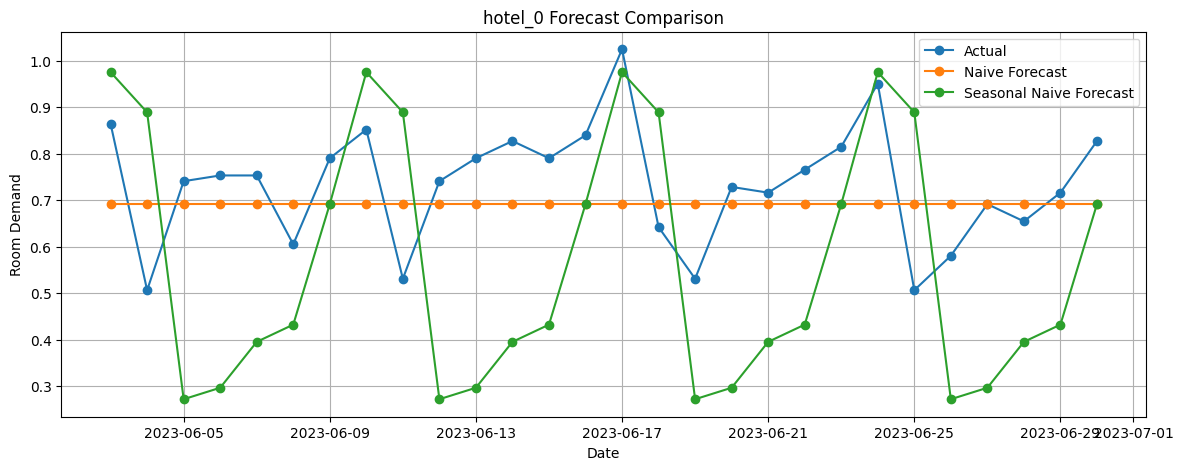

In [15]:
cv_df['cutoff'].unique()

hotel = 'hotel_0'
last_cutoff = cv_df['cutoff'].max()
temp = cv_df[
    (cv_df['unique_id'] == hotel) &
    (cv_df['cutoff'] == last_cutoff)
]

plt.figure(figsize=(14,5))

plt.plot(temp['ds'], temp['y'], marker='o', label='Actual')
plt.plot(temp['ds'], temp['Naive'], marker='o', label='Naive Forecast')
plt.plot(temp['ds'], temp['SeasonalNaive'], marker='o', label='Seasonal Naive Forecast')

plt.title(f'{hotel} Forecast Comparison')
plt.xlabel('Date')
plt.ylabel('Room Demand')

plt.legend()
plt.grid(True)

plt.show()

Create Statistical Forecasting models: AutoETS and AutoARIMA

In [16]:
sf = StatsForecast(
    models=[
        Naive(),
        SeasonalNaive(season_length=7),
        AutoETS(season_length=7),
        AutoARIMA(season_length=7)
    ],
    freq='D'
)

cv_df = sf.cross_validation(
    df=df[['unique_id', 'ds', 'y']],
    h=28,
    n_windows=5
)

Plot all four models together

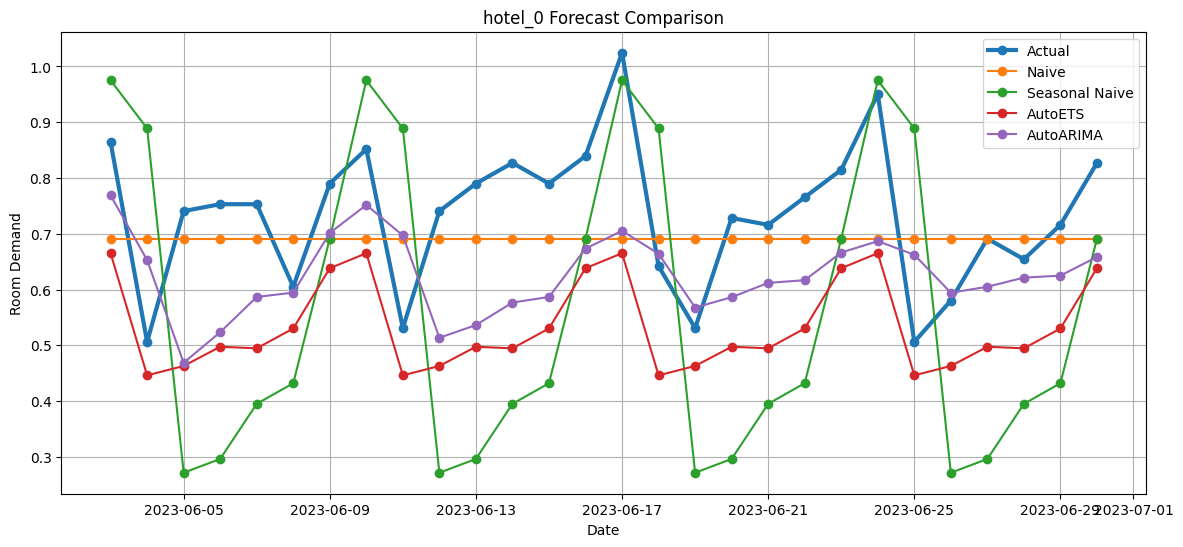

In [18]:
hotel = 'hotel_0'

last_cutoff = cv_df['cutoff'].max()

temp = cv_df[
    (cv_df['unique_id'] == hotel) &
    (cv_df['cutoff'] == last_cutoff)
]

plt.figure(figsize=(14,6))

plt.plot(temp['ds'], temp['y'],
         marker='o',
         linewidth=3,
         label='Actual')

plt.plot(temp['ds'], temp['Naive'],
         marker='o',
         label='Naive')

plt.plot(temp['ds'], temp['SeasonalNaive'],
         marker='o',
         label='Seasonal Naive')

plt.plot(temp['ds'], temp['AutoETS'],
         marker='o',
         label='AutoETS')

plt.plot(temp['ds'], temp['AutoARIMA'],
         marker='o',
         label='AutoARIMA')

plt.title(f'{hotel} Forecast Comparison')
plt.xlabel('Date')
plt.ylabel('Room Demand')

plt.legend()
plt.grid(True)

plt.show()

Compute error for all models

In [19]:
models = ['Naive', 'SeasonalNaive', 'AutoETS', 'AutoARIMA']

for model in models:
    cv_df[f'{model}_Error'] = cv_df[model] - cv_df['y']
    cv_df[f'{model}_AE'] = abs(cv_df[f'{model}_Error'])
    cv_df[f'{model}_SE'] = cv_df[f'{model}_Error'] ** 2

Make summary table for errors

In [20]:
summary = []

for model in models:

    me = cv_df[f'{model}_Error'].mean()
    mae = cv_df[f'{model}_AE'].mean()
    rmse = np.sqrt(cv_df[f'{model}_SE'].mean())

    summary.append({
        'Model': model,
        'ME': me,
        'MAE': mae,
        'RMSE': rmse
    })

summary_df = pd.DataFrame(summary)

summary_df

,Model,ME,MAE,RMSE
0,Naive,-0.089192,0.138320,0.200139
1,SeasonalNaive,-0.040316,0.125949,0.185235
2,AutoETS,-0.074229,0.118678,0.167691
3,AutoARIMA,-0.040975,0.094866,0.134471


Save outputs

In [21]:
summary_df.to_csv('statistical_model_results.csv', index=False)
cv_df.to_csv('statistical_model_predictions.csv', index=False)

Create ML model

In [22]:
from mlforecast import MLForecast
from lightgbm import LGBMRegressor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_ml = df.sort_values(['unique_id', 'ds'])
df_ml = df_ml.drop_duplicates(subset=['unique_id', 'ds'], keep='first')

fixed_list = []

for hotel in df_ml['unique_id'].unique():
    temp = df_ml[df_ml['unique_id'] == hotel].copy()
    temp = temp.set_index('ds').asfreq('D')
    temp['unique_id'] = hotel
    temp = temp.ffill()
    temp = temp.bfill()
    temp = temp.reset_index()
    fixed_list.append(temp)

df_ml = pd.concat(fixed_list, ignore_index=True)

print(df_ml.groupby('unique_id').size())

mlf = MLForecast(
    models=[
        LGBMRegressor(random_state=42)
    ],
    freq='D',
    lags=[1, 7, 14, 28]
)

mlf.fit(
    df_ml,
    static_features=[]
)

ml_predictions = mlf.predict(h=28)

ml_predictions.head()

unique_id
hotel_0      546
hotel_105    546
hotel_112    546
hotel_126    546
hotel_133    546
hotel_14     546
hotel_21     546
hotel_28     546
hotel_35     546
hotel_42     546
hotel_49     546
hotel_56     546
hotel_63     546
hotel_7      546
hotel_70     546
hotel_77     360
hotel_84     546
hotel_91     546
hotel_98     546
dtype: int64
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000619 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 9656, number of used features: 4
[LightGBM] [Info] Start training from score 0.674640


,unique_id,ds,LGBMRegressor
0,hotel_0,2023-07-01,0.863900
1,hotel_0,2023-07-02,0.746905
2,hotel_0,2023-07-03,0.708385
3,hotel_0,2023-07-04,0.711513
4,hotel_0,2023-07-05,0.719819


Plot one hotel

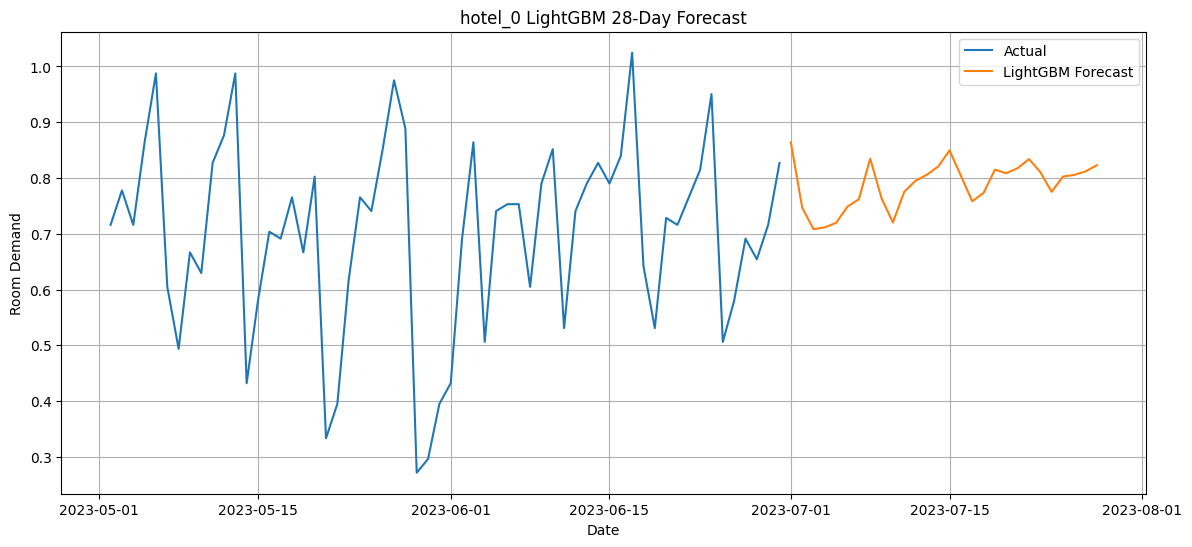

In [23]:
hotel = 'hotel_0'

actual = df_ml[df_ml['unique_id'] == hotel].tail(60)

forecast = ml_predictions[
    ml_predictions['unique_id'] == hotel
]

plt.figure(figsize=(14,6))

plt.plot(actual['ds'], actual['y'], label='Actual')
plt.plot(forecast['ds'], forecast['LGBMRegressor'], label='LightGBM Forecast')

plt.title(f'{hotel} LightGBM 28-Day Forecast')
plt.xlabel('Date')
plt.ylabel('Room Demand')
plt.legend()
plt.grid(True)
plt.show()

Save ML forecast output

In [24]:
ml_predictions.to_csv('lightgbm_final_forecasts.csv', index=False)

Create Neural model

In [25]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS

df_neural = df[['unique_id', 'ds', 'y']].copy()

models = [

    NBEATS(
        h=28,
        input_size=56,
        max_steps=100
    ),

    NHITS(
        h=28,
        input_size=56,
        max_steps=100
    )
]

nf = NeuralForecast(
    models=models,
    freq='D'
)

nf.fit(df=df_neural)

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.6 M  | train
-------------------------------------------------------
2.6 M     Trainable params
4.8 K     Non-trainable params
2.6 M     Total params
10.231    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.5 M  | train
-------------------------------------------------------
2.5 M     Trainable params
0         Non-trainable params
2.5 M     Total params
10.136    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.


Generate and plot forecasts

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

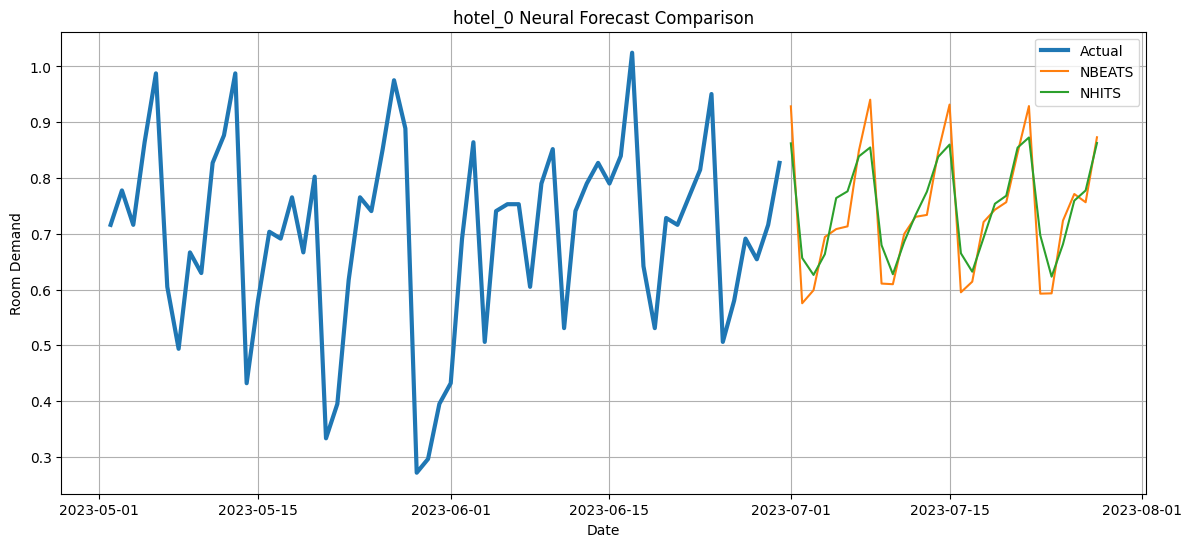

In [26]:
neural_predictions = nf.predict()
neural_predictions.head()

hotel = 'hotel_0'

actual = df_neural[
    df_neural['unique_id'] == hotel
].tail(60)

forecast = neural_predictions[
    neural_predictions['unique_id'] == hotel
]

plt.figure(figsize=(14,6))

plt.plot(
    actual['ds'],
    actual['y'],
    label='Actual',
    linewidth=3
)

plt.plot(
    forecast['ds'],
    forecast['NBEATS'],
    label='NBEATS'
)

plt.plot(
    forecast['ds'],
    forecast['NHITS'],
    label='NHITS'
)

plt.title(f'{hotel} Neural Forecast Comparison')

plt.xlabel('Date')
plt.ylabel('Room Demand')

plt.legend()
plt.grid(True)

plt.show()

Save plots

In [27]:
neural_predictions.to_csv('neural_forecasts.csv', index=False)
ml_predictions.to_csv('lightgbm_forecasts.csv', index=False)

Create Foundation Model

In [28]:
# Install and import chronos
!pip install chronos-forecasting
!pip install transformers accelerate

import torch
import pandas as pd
import matplotlib.pyplot as plt
from chronos import ChronosPipeline

# Load chronos model
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",
    torch_dtype=torch.float32
)

Get one hotel series

In [32]:
hotel = 'hotel_0'

series = df[
    df['unique_id'] == hotel
].sort_values('ds')

context = torch.tensor(
    series['y'].values,
    dtype=torch.float32
)

create 28-day forecast

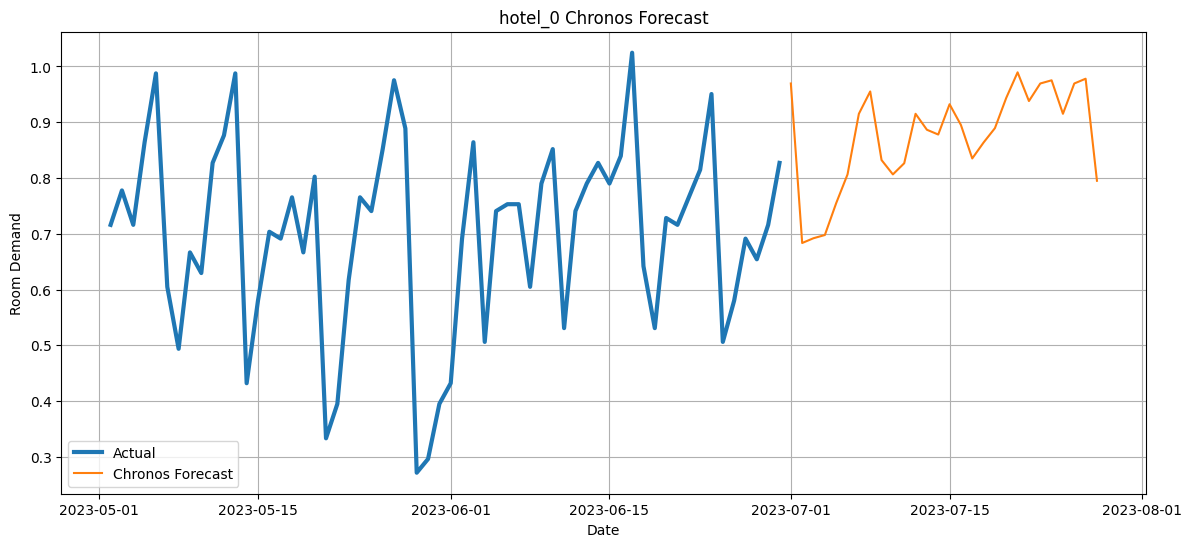

In [38]:
forecast = pipeline.predict(
    [context],
    prediction_length=28
)

forecast_values = np.median(forecast[0].numpy(), axis=0)

future_dates = pd.date_range(
    start=series['ds'].max() + pd.Timedelta(days=1),
    periods=28,
    freq='D'
)

plt.figure(figsize=(14,6))

# Historical
plt.plot(
    series['ds'].tail(60),
    series['y'].tail(60),
    label='Actual',
    linewidth=3
)

# Chronos forecast
plt.plot(
    future_dates,
    forecast_values,
    label='Chronos Forecast'
)

plt.title(f'{hotel} Chronos Forecast')

plt.xlabel('Date')
plt.ylabel('Room Demand')

plt.legend()
plt.grid(True)

plt.show()

Build Comparison Table

In [43]:
eval_df = cv_df[
    [
        'unique_id',
        'ds',
        'y',
        'Naive',
        'SeasonalNaive',
        'AutoETS',
        'AutoARIMA'
    ]
].copy()

# add ML forecasts
eval_df = eval_df.merge(
    ml_predictions[
        ['unique_id', 'ds', 'LGBMRegressor']
    ],
    on=['unique_id', 'ds'],
    how='left'
)

eval_df = eval_df.rename(columns={
    'LGBMRegressor': 'LightGBM'
})

# add neural forecasts
eval_df = eval_df.merge(
    neural_predictions[
        ['unique_id', 'ds', 'NBEATS', 'NHITS']
    ],
    on=['unique_id', 'ds'],
    how='left'
)

# add foundation model
chronos_df = pd.DataFrame({
    'unique_id': hotel,
    'ds': future_dates,
    'Chronos': forecast_values
})

# merge
eval_df = eval_df.merge(
    chronos_df,
    on=['unique_id', 'ds'],
    how='left'
)

Create Model List

In [45]:
models = [
    'Naive',
    'SeasonalNaive',
    'AutoETS',
    'AutoARIMA',
    'LightGBM',
    'NBEATS',
    'NHITS',
    'Chronos'
]

metrics_table = []

for model in models:
    temp = eval_df.dropna(subset=[model])
    error = temp[model] - temp['y']
    abs_error = abs(error)
    squared_error = error ** 2
    mape = np.where(
        temp['y'] != 0,
        abs_error / temp['y'] * 100,
        np.nan
    )

    metrics_table.append({
        'Model': model,
        'ME': round(error.mean(), 4),
        'MAE': round(abs_error.mean(), 4),
        'RMSE': round(
            np.sqrt(squared_error.mean()),
            4
        ),
        'MAPE': round(
            np.nanmean(mape),
            4
        )
    })

metrics_df = pd.DataFrame(metrics_table)
metrics_df

/tmp/ipykernel_39370/3438084280.py:34: RuntimeWarning: Mean of empty slice
  np.nanmean(mape),
/tmp/ipykernel_39370/3438084280.py:34: RuntimeWarning: Mean of empty slice
  np.nanmean(mape),
/tmp/ipykernel_39370/3438084280.py:34: RuntimeWarning: Mean of empty slice
  np.nanmean(mape),
/tmp/ipykernel_39370/3438084280.py:34: RuntimeWarning: Mean of empty slice
  np.nanmean(mape),


,Model,ME,MAE,RMSE,MAPE
0,Naive,-0.0892,0.1383,0.2001,24.7145
1,SeasonalNaive,-0.0403,0.1259,0.1852,23.6794
2,AutoETS,-0.0742,0.1187,0.1677,21.0207
3,AutoARIMA,-0.0410,0.0949,0.1345,19.1738
4,LightGBM,NaN,NaN,NaN,NaN
5,NBEATS,NaN,NaN,NaN,NaN
6,NHITS,NaN,NaN,NaN,NaN
7,Chronos,NaN,NaN,NaN,NaN


Count wins for each model

In [47]:
win_counts = []

for metric in ['MAE', 'RMSE', 'MAPE']:

    winner = metrics_df.loc[
        metrics_df[metric].idxmin(),
        'Model'
    ]

    win_counts.append({
        'Metric': metric,
        'Winning Model': winner
    })

metrics_df['Abs_ME'] = abs(metrics_df['ME'])
winner = metrics_df.loc[
    metrics_df['Abs_ME'].idxmin(),
    'Model'
]

win_counts.append({
    'Metric': 'ME',
    'Winning Model': winner
})

win_counts_df = pd.DataFrame(win_counts)
win_counts_df

,Metric,Winning Model
0,MAE,AutoARIMA
1,RMSE,AutoARIMA
2,MAPE,AutoARIMA
3,ME,SeasonalNaive


save output

In [48]:
metrics_df.to_csv(
    'combined_metrics_table.csv',
    index=False
)

win_counts_df.to_csv(
    'model_win_counts.csv',
    index=False
)

Conclusion:
The forecasting results showed that hotel occupancy demand has strong weekly seasonality. Seasonal Naive provided a surprisingly competitive benchmark due to the cyclical structure of the data. Statistical models such as AutoETS and AutoARIMA improved forecast smoothness and responsiveness, while the ML model used lags and was able to produce stable occupancy forecasts. Neural forecasting models, specifically NHITS, was most effective at balancing seasonal structure and short-term fluctuations. The foundation model was also pretty strong at predicting demand based on the seasonality of the data, although specialized models often captured the hotel demand more effectively.